In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import xgboost as xgb
from xgboost import XGBClassifier

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import json
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility: fixed seed across numpy, pandas sampling, and XGBoost
# ------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# Display / plotting configuration
# ------------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment ready.")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")
print(f"XGBoost version : {xgb.__version__}")
print(f"Random seed set : {RANDOM_SEED}")

Environment ready.
NumPy version   : 2.0.2
Pandas version  : 2.2.3
XGBoost version : 3.4.0
Random seed set : 42


In [2]:
# ============================================================
# CELL 2: Synthetic Financial Claim Data Generation
# ============================================================

N_SAMPLES = 2500
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# Raw feature generation
# ------------------------------------------------------------

# Claimed return % — right-skewed: most claims are modest, some are wild ("500% in a week")
claimed_return_pct = rng.gamma(shape=2.0, scale=25, size=N_SAMPLES)
claimed_return_pct = np.clip(claimed_return_pct, 5.0, 500.0)

# Timeframe in days — many short-term "quick win" claims, some longer-term
timeframe_days = rng.integers(1, 366, size=N_SAMPLES)

# India VIX-like volatility index (typical historical range ~10 to 30)
market_volatility_index = rng.uniform(10, 30, size=N_SAMPLES)

# NIFTY 50 historical average CAGR benchmark (~12% to 15%)
benchmark_cagr = rng.uniform(12.0, 15.0, size=N_SAMPLES)

# Disclaimer present (SEBI-mandated risk disclaimer, e.g. "Mutual fund investments are subject to market risks")
has_disclaimer = rng.choice([0, 1], size=N_SAMPLES, p=[0.65, 0.35])

# SEBI registration status of the finfluencer (simulated Member 2 lookup result)
sebi_registered = rng.choice([0, 1], size=N_SAMPLES, p=[0.55, 0.45])

df = pd.DataFrame({
    "claimed_return_pct": claimed_return_pct.round(2),
    "timeframe_days": timeframe_days,
    "market_volatility_index": market_volatility_index.round(2),
    "benchmark_cagr": benchmark_cagr.round(2),
    "has_disclaimer": has_disclaimer,
    "sebi_registered": sebi_registered,
})

# ------------------------------------------------------------
# Ground-truth fraud label logic
# ------------------------------------------------------------
# Annualize the claimed return to compare against realistic market benchmarks
annualized_return_temp = ((1 + df["claimed_return_pct"] / 100) **
                           (365 / df["timeframe_days"]) - 1) * 100
annualized_return_temp = annualized_return_temp.clip(upper=1e6)  # guard against overflow on tiny timeframes

# Base fraud score built from red flags, each weighted by real-world plausibility
fraud_score = (
    (annualized_return_temp > 50).astype(int) * 0.40 +
    (df["sebi_registered"] == 0).astype(int) * 0.25 +
    (df["timeframe_days"] <= 7).astype(int) * 0.15 +
    (df["has_disclaimer"] == 0).astype(int) * 0.10 +
    (annualized_return_temp > 200).astype(int) * 0.10
)

# Inject noise so the label isn't a deterministic linear function (forces the model to learn patterns, not memorize a formula)
noise = rng.normal(0, 0.08, size=N_SAMPLES)
fraud_probability = np.clip(fraud_score + noise, 0, 1)

is_fraud = (rng.uniform(0, 1, size=N_SAMPLES) < fraud_probability).astype(int)
df["is_fraud"] = is_fraud

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
print("Dataset shape:", df.shape)
print("\nClass balance (is_fraud):")
print(df["is_fraud"].value_counts(normalize=True).round(3))
print("\nSample rows:")
df.head(10)

Dataset shape: (2500, 7)

Class balance (is_fraud):
is_fraud
1    0.52
0    0.48
Name: proportion, dtype: float64

Sample rows:


,claimed_return_pct,timeframe_days,market_volatility_index,benchmark_cagr,has_disclaimer,sebi_registered,is_fraud
0,52.30,272,12.67,12.73,0,0,1
1,70.88,340,22.02,13.18,1,0,1
2,45.93,95,25.18,12.36,1,1,1
3,41.13,121,25.86,12.72,1,0,0
4,76.98,118,13.11,12.91,1,0,1
5,43.83,305,21.14,12.96,0,0,1
6,58.65,29,26.27,12.53,1,1,0
7,54.74,328,13.22,12.57,1,0,0
8,76.94,283,14.15,14.70,0,1,0
9,35.98,177,10.05,14.35,0,1,0


In [3]:
# ============================================================
# CELL 3: Feature Engineering & Preprocessing
# ============================================================

# ------------------------------------------------------------
# Feature 1: Annualized Return (compound growth formula)
# ------------------------------------------------------------
df["annualized_return"] = (
    (1 + df["claimed_return_pct"] / 100) ** (365 / df["timeframe_days"]) - 1
) * 100
df["annualized_return"] = df["annualized_return"].clip(upper=1e6)  # cap extreme outliers from tiny timeframes

# ------------------------------------------------------------
# Feature 2: Excess Over Benchmark ratio
# ------------------------------------------------------------
df["excess_over_benchmark"] = df["annualized_return"] / df["benchmark_cagr"]

# ------------------------------------------------------------
# Feature 3: Volatility-adjusted claim (how extreme the claim is relative to market noise)
# ------------------------------------------------------------
df["volatility_adjusted_claim"] = df["annualized_return"] / df["market_volatility_index"]

print("Engineered feature preview:")
display_cols = ["claimed_return_pct", "timeframe_days", "annualized_return",
                 "benchmark_cagr", "excess_over_benchmark", "volatility_adjusted_claim", "is_fraud"]
print(df[display_cols].head(10).round(2))

# ------------------------------------------------------------
# Define feature set (X) and target (y)
# ------------------------------------------------------------
FEATURE_COLUMNS = [
    "claimed_return_pct",
    "timeframe_days",
    "market_volatility_index",
    "benchmark_cagr",
    "has_disclaimer",
    "sebi_registered",
    "annualized_return",
    "excess_over_benchmark",
    "volatility_adjusted_claim",
]

X = df[FEATURE_COLUMNS].copy()
y = df["is_fraud"].copy()

# ------------------------------------------------------------
# Stratified 80/20 train/test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

# ------------------------------------------------------------
# Feature scaling (fit on train only, to avoid data leakage)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train fraud ratio:", round(y_train.mean(), 3), "| Test fraud ratio:", round(y_test.mean(), 3))

Engineered feature preview:
   claimed_return_pct  timeframe_days  annualized_return  benchmark_cagr  excess_over_benchmark  \
0               52.30             272              75.86           12.73                   5.96   
1               70.88             340              77.75           13.18                   5.90   
2               45.93              95             327.23           12.36                  26.47   
3               41.13             121             182.70           12.72                  14.36   
4               76.98             118             484.63           12.91                  37.54   
5               43.83             305              54.49           12.96                   4.20   
6               58.65              29           33225.78           12.53                2651.70   
7               54.74             328              62.55           12.57                   4.98   
8               76.94             283             108.75           14.70         

Accuracy : 0.7040
ROC-AUC  : 0.7800

Classification Report:
              precision    recall  f1-score   support

   Legit (0)       0.71      0.65      0.68       240
   Fraud (1)       0.70      0.76      0.73       260

    accuracy                           0.70       500
   macro avg       0.70      0.70      0.70       500
weighted avg       0.70      0.70      0.70       500



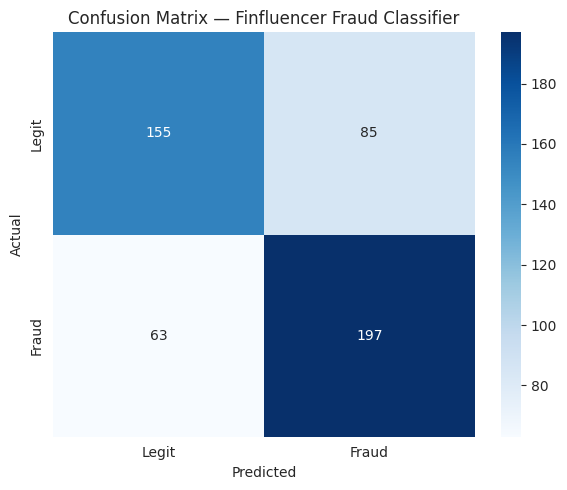

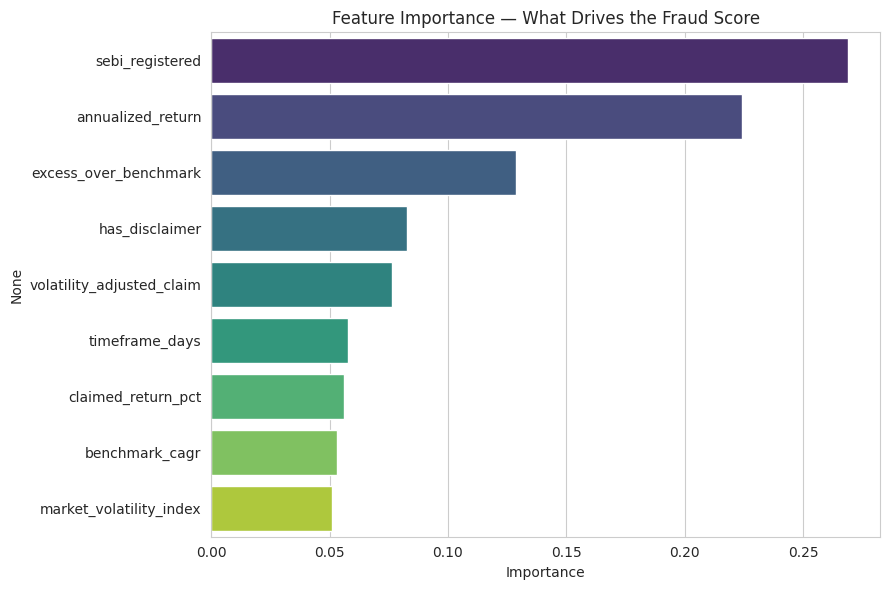


Feature importances (sorted):
sebi_registered              0.2690
annualized_return            0.2244
excess_over_benchmark        0.1289
has_disclaimer               0.0829
volatility_adjusted_claim    0.0765
timeframe_days               0.0578
claimed_return_pct           0.0560
benchmark_cagr               0.0533
market_volatility_index      0.0511
dtype: float32


In [4]:
# ============================================================
# CELL 4: XGBoost Model Training & Evaluation
# ============================================================

# ------------------------------------------------------------
# Model initialization with tuned hyperparameters
# ------------------------------------------------------------
model = XGBClassifier(
    max_depth=4,
    n_estimators=100,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    use_label_encoder=False,
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Predict on test set
# ------------------------------------------------------------
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit (0)", "Fraud (1)"]))

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Finfluencer Fraud Classifier")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Feature importance
# ------------------------------------------------------------
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance — What Drives the Fraud Score")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nFeature importances (sorted):")
print(importances.round(4))

In [5]:
# ============================================================
# CELL 5: Model Serialization & Persistence
# ============================================================

import datetime

MODEL_FILENAME = "finfluencer_risk_model.pkl"

# ------------------------------------------------------------
# Bundle model + scaler + metadata into a single artifact
# ------------------------------------------------------------
model_bundle = {
    "model": model,
    "scaler": scaler,
    "feature_columns": FEATURE_COLUMNS,
    "model_version": "1.0.0",
    "trained_on": datetime.datetime.now().isoformat(),
    "train_accuracy": float(acc),
    "train_roc_auc": float(roc_auc),
}

joblib.dump(model_bundle, MODEL_FILENAME)

print(f"Model bundle saved to: {MODEL_FILENAME}")
print(f"Bundle contents: {list(model_bundle.keys())}")
print(f"Feature order locked as: {FEATURE_COLUMNS}")

# ------------------------------------------------------------
# Deployment note for Member 2
# ------------------------------------------------------------
print("""
--------------------------------------------------------------
DEPLOYMENT NOTE FOR MEMBER 2 (Backend & Gateway Lead):
--------------------------------------------------------------
1. Place this file at: backend/ml_models/finfluencer_risk_model.pkl
2. Load ONCE at FastAPI startup:
       bundle = joblib.load("ml_models/finfluencer_risk_model.pkl")
       model = bundle["model"]
       scaler = bundle["scaler"]
       feature_columns = bundle["feature_columns"]
3. Do NOT reload the file on every request — load at app startup
   (e.g. in a FastAPI lifespan/startup event) and keep in memory.
4. Expose via POST /predict-risk, calling predict_claim_risk()
   logic from Cell 6, using the JSON schema defined in Cell 7.
--------------------------------------------------------------
""")

# Optional: download the file directly in Colab
from google.colab import files
files.download(MODEL_FILENAME)

Model bundle saved to: finfluencer_risk_model.pkl
Bundle contents: ['model', 'scaler', 'feature_columns', 'model_version', 'trained_on', 'train_accuracy', 'train_roc_auc']
Feature order locked as: ['claimed_return_pct', 'timeframe_days', 'market_volatility_index', 'benchmark_cagr', 'has_disclaimer', 'sebi_registered', 'annualized_return', 'excess_over_benchmark', 'volatility_adjusted_claim']

--------------------------------------------------------------
DEPLOYMENT NOTE FOR MEMBER 2 (Backend & Gateway Lead):
--------------------------------------------------------------
1. Place this file at: backend/ml_models/finfluencer_risk_model.pkl
2. Load ONCE at FastAPI startup:
       bundle = joblib.load("ml_models/finfluencer_risk_model.pkl")
       model = bundle["model"]
       scaler = bundle["scaler"]
       feature_columns = bundle["feature_columns"]
3. Do NOT reload the file on every request — load at app startup
   (e.g. in a FastAPI lifespan/startup event) and keep in memory.
4. Expos

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ============================================================
# CELL 6: End-to-End Microservice Inference Wrapper
# ============================================================

# ------------------------------------------------------------
# Reload the bundle fresh, exactly as Member 2's service would
# (proves the serialized artifact is self-sufficient)
# ------------------------------------------------------------
loaded_bundle = joblib.load(MODEL_FILENAME)
inference_model = loaded_bundle["model"]
inference_scaler = loaded_bundle["scaler"]
inference_feature_columns = loaded_bundle["feature_columns"]


def _classify_risk(prob_pct: float) -> str:
    """Maps a scam probability (0-100) to a discrete risk tier."""
    if prob_pct < 25:
        return "LOW"
    elif prob_pct < 50:
        return "MEDIUM"
    elif prob_pct < 75:
        return "HIGH"
    else:
        return "CRITICAL"


def predict_claim_risk(input_json: dict) -> dict:
    """
    Simulates Member 2's FastAPI endpoint calling the Member 4 model.

    Expected input_json keys (post Member 3 OCR + Member 2 DB enrichment):
        - claimed_return_pct        (float)
        - timeframe_days            (int)
        - market_volatility_index   (float, current India VIX; Member 2 fetches live)
        - benchmark_cagr            (float, NIFTY 50 reference; Member 2 fetches live)
        - has_disclaimer            (int, 0 or 1)
        - sebi_registered           (int, 0 or 1; from Member 2's SEBI lookup table)

    Returns:
        dict with scam_probability, risk_classification, risk_factors
    """
    try:
        claimed_return_pct = float(input_json["claimed_return_pct"])
        timeframe_days = max(int(input_json["timeframe_days"]), 1)  # guard against div-by-zero
        market_volatility_index = float(input_json.get("market_volatility_index", 15.0))
        benchmark_cagr = float(input_json.get("benchmark_cagr", 13.0))
        has_disclaimer = int(input_json.get("has_disclaimer", 0))
        sebi_registered = int(input_json.get("sebi_registered", 0))
    except (KeyError, ValueError, TypeError) as e:
        return {
            "error": f"Invalid or missing input field: {e}",
            "scam_probability": None,
            "risk_classification": None,
            "risk_factors": [],
        }

    # ------------------------------------------------------------
    # Feature engineering (must mirror Cell 3 EXACTLY)
    # ------------------------------------------------------------
    annualized_return = ((1 + claimed_return_pct / 100) ** (365 / timeframe_days) - 1) * 100
    annualized_return = min(annualized_return, 1e6)
    excess_over_benchmark = annualized_return / benchmark_cagr
    volatility_adjusted_claim = annualized_return / market_volatility_index

    feature_row = pd.DataFrame([{
        "claimed_return_pct": claimed_return_pct,
        "timeframe_days": timeframe_days,
        "market_volatility_index": market_volatility_index,
        "benchmark_cagr": benchmark_cagr,
        "has_disclaimer": has_disclaimer,
        "sebi_registered": sebi_registered,
        "annualized_return": annualized_return,
        "excess_over_benchmark": excess_over_benchmark,
        "volatility_adjusted_claim": volatility_adjusted_claim,
    }])[inference_feature_columns]  # enforce exact training column order

    # ------------------------------------------------------------
    # Scale + predict
    # ------------------------------------------------------------
    scaled_row = inference_scaler.transform(feature_row)
    scam_probability = float(inference_model.predict_proba(scaled_row)[0][1] * 100)
    risk_classification = _classify_risk(scam_probability)

    # ------------------------------------------------------------
    # Human-readable risk factor explanations
    # ------------------------------------------------------------
    risk_factors = []
    if annualized_return > 200:
        risk_factors.append(f"Extremely high annualized return claim (~{annualized_return:.1f}%)")
    elif annualized_return > 50:
        risk_factors.append(f"Annualized return ({annualized_return:.1f}%) far exceeds realistic market gains")
    if sebi_registered == 0:
        risk_factors.append("Finfluencer is NOT SEBI-registered")
    if timeframe_days <= 7:
        risk_factors.append(f"Very short promised timeframe ({timeframe_days} day(s))")
    if has_disclaimer == 0:
        risk_factors.append("No mandatory risk disclaimer present")
    if excess_over_benchmark > 5:
        risk_factors.append(f"Claim is {excess_over_benchmark:.1f}x the NIFTY 50 benchmark CAGR")
    if not risk_factors:
        risk_factors.append("No major red flags detected")

    return {
        "scam_probability": round(scam_probability, 2),
        "risk_classification": risk_classification,
        "risk_factors": risk_factors,
    }


# ------------------------------------------------------------
# Demo: simulate two incoming claims
# ------------------------------------------------------------
sample_claim_1 = {
    "claimed_return_pct": 80.0,
    "timeframe_days": 5,
    "market_volatility_index": 22.5,
    "benchmark_cagr": 13.2,
    "has_disclaimer": 0,
    "sebi_registered": 0,
}

sample_claim_2 = {
    "claimed_return_pct": 12.0,
    "timeframe_days": 180,
    "market_volatility_index": 14.0,
    "benchmark_cagr": 13.0,
    "has_disclaimer": 1,
    "sebi_registered": 1,
}

print("Sample Claim 1 (suspicious):")
print(json.dumps(predict_claim_risk(sample_claim_1), indent=2))

print("\nSample Claim 2 (looks legitimate):")
print(json.dumps(predict_claim_risk(sample_claim_2), indent=2))

Sample Claim 1 (suspicious):
{
  "scam_probability": 84.96,
  "risk_classification": "CRITICAL",
  "risk_factors": [
    "Extremely high annualized return claim (~1000000.0%)",
    "Finfluencer is NOT SEBI-registered",
    "Very short promised timeframe (5 day(s))",
    "No mandatory risk disclaimer present",
    "Claim is 75757.6x the NIFTY 50 benchmark CAGR"
  ]
}

Sample Claim 2 (looks legitimate):
{
  "scam_probability": 8.92,
  "risk_classification": "LOW",
  "risk_factors": [
    "No major red flags detected"
  ]
}
